# 7.3 Deterministic Interpolation

**Part:** 7 — Spatial Interpolation (Chapter 7.3 of 8)

**Dataset:** `meuse.csv` (155 topsoil samples, Meuse floodplain, EPSG:28992) predicted onto `meuse_grid.csv` (3,103 cells, 40 m)

**Focus:** `TrendSurface`, `Thiessen` polygons, `NearestNeighbor`, `IDW`, `ThinPlateSpline` — one shared interface

**Library:** `spatialstats.interpolate` (PySpatialStats)


***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [One Interface for Every Method](#3.-One-Interface-for-Every-Method)
4.. [Polynomial Trend Surface](#4.-Polynomial-Trend-Surface)
5.. [Proximity Analysis: Thiessen Polygons](#5.-Proximity-Analysis:-Thiessen-Polygons)
6.. [Nearest Neighbour](#6.-Nearest-Neighbour)
7.. [TIN (Delaunay Linear)](#7.-TIN-(Delaunay-Linear))
8.. [Inverse Distance Weighting](#8.-Inverse-Distance-Weighting)
9.. [Thin-Plate Spline](#9.-Thin-Plate-Spline)
10.. [Comparing the Surfaces](#10.-Comparing-the-Surfaces)
11.. [Summary and Conclusions](#11.-Summary-and-Conclusions)
12.. [Resources](#12.-Resources)


***
## 1. Overview

Six deterministic rules for turning point measurements into a surface. A polynomial trend is a global
regression. Thiessen polygons and nearest neighbour copy the closest sample. TIN and IDW blend nearby
samples. The thin-plate spline bends a smooth sheet through every observation. None of them models spatial
correlation explicitly (Chapter 7.1, Section 6), and all of them share one interface so they can be swapped
freely. TIN is the linear cousin of natural-neighbour interpolation; Sibson natural neighbour is not
implemented here.

The worked example is topsoil zinc (ppm) on the Meuse River floodplain in the Netherlands — the `meuse`
data from the `gstat` and `sp` examples. Coordinates in `meuse.csv` are already in metres (Amersfoort / RD
New, EPSG:28992), so distance-based methods need no reprojection. Every map below predicts at the cell
centres in `meuse_grid.csv`, the 40 m floodplain lattice, rather than on a filled rectangle around the samples.

| Method | Idea | Exact? | Extrapolates smoothly? |
|---|---|---|---|
| `TrendSurface` | Least-squares polynomial in $x$ and $y$ | No | Yes — and without bound |
| `Thiessen` | Voronoi cell of the nearest sample | Yes | No — sharp polygon boundaries |
| `NearestNeighbor` | The same partition, evaluated on the floodplain grid | Yes | No — sharp boundaries |
| `TIN` | Piecewise-linear over a Delaunay triangulation | Yes | No — flat outside the convex hull |
| `IDW` | Weighted average, weight $\propto 1/d^p$ | Yes (at $p<\infty$, no smoothing) | Yes, but flattens far from data |
| `ThinPlateSpline` | Minimum-bending surface through the data | Yes (`smoothing=0`) | Can overshoot far from data |


***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.interpolate import (
    TrendSurface, Thiessen, NearestNeighbor, TIN, IDW, ThinPlateSpline,
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

meuse = pd.read_csv(DATA / "meuse.csv")
grid = pd.read_csv(DATA / "meuse_grid.csv")
coords = meuse[["x", "y"]].to_numpy(dtype=float)
values = meuse["zinc"].to_numpy(dtype=float)
grid_xy = grid[["x", "y"]].to_numpy(dtype=float)

_xs = np.sort(grid["x"].unique())
_ys = np.sort(grid["y"].unique())
_dx, _dy = float(_xs[1] - _xs[0]), float(_ys[1] - _ys[0])
EXTENT = (_xs[0] - _dx / 2, _xs[-1] + _dx / 2, _ys[0] - _dy / 2, _ys[-1] + _dy / 2)


def to_raster(pred) -> np.ndarray:
    """Place predictions for the meuse_grid cells on the 40 m lattice (NaN off the floodplain)."""
    raster = np.full((len(_ys), len(_xs)), np.nan)
    raster[np.searchsorted(_ys, grid_xy[:, 1]), np.searchsorted(_xs, grid_xy[:, 0])] = pred
    return raster


print(f"spatialstats : version {spatialstats.__version__}")
print(f"n = {len(coords)} samples, {len(grid_xy)} prediction cells at {_dx:.0f} m")
print(f"zinc: {values.min():.0f} to {values.max():.0f} ppm")


spatialstats : version 0.2.0
n = 155 samples, 3103 prediction cells at 40 m
zinc: 113 to 1839 ppm


***
## 3. One Interface for Every Method

Every interpolator in this Part — the deterministic methods here, geostatistical prediction in Chapter 7.4 —
shares the same four methods: `.fit(coords, values)`, `.predict(new_coords)`, `.predict_grid(region, ...)`,
and `.clone()` / `.get_params()` (the same scikit-learn-style pattern Part 6's GW models used). This is what
lets Chapter 7.5's `cross_validate` and `compare_methods` treat every method identically. `Thiessen.polygons`
is the one extra method: proximity analysis wants the polygons, not only a raster.

The maps in this chapter call `.predict(grid_xy)` at the floodplain cell centres in `meuse_grid.csv`.
`.predict_grid` is the same prediction step on a rectangle you build yourself when you do not already have
a target lattice.


In [2]:
demo = IDW(power=2, k=12)
print("get_params():", demo.get_params())
demo2 = demo.clone()
demo2.power = 3
print("clone is independent:", demo.power, "vs", demo2.power)

get_params(): {'power': 2, 'k': 12, 'radius': None, 'smoothing': 0.0}
clone is independent: 2 vs 3


***
## 4. Polynomial Trend Surface

A trend surface is a global polynomial regression on the coordinates, not a local interpolator:

$$
\hat{z}(x, y) = \sum_{i+j \le d} \beta_{ij}\, (x-\bar{x})^i (y-\bar{y})^j
$$

`degree=1` is a tilted plane, `degree=2` adds curvature, `degree=3` adds more flex. The fit is least squares,
so the surface does **not** pass through the samples unless they already lie on a polynomial of that degree.
`r2_` is the in-sample coefficient of determination. Because the polynomial is global, raising the degree
lets it swing between samples and, especially, past the cloud of points.


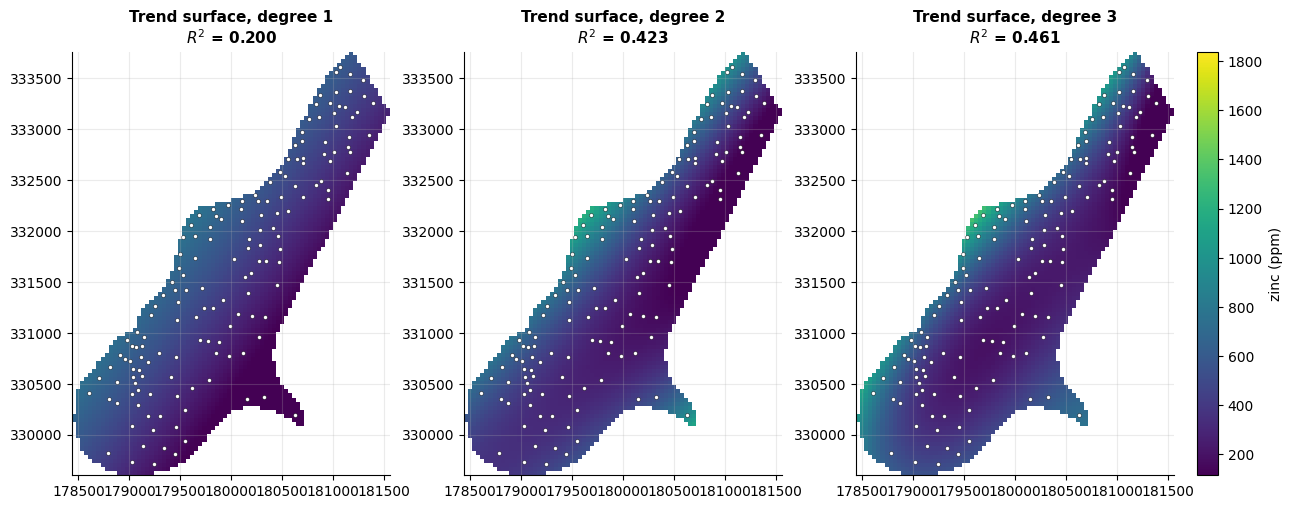

degree 2 in-sample R^2 = 0.423
prediction range: -27.6 to 1198.4 (observed range: 113.0 to 1839.0)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, degree in zip(axes, (1, 2, 3)):
    trend = TrendSurface(degree=degree).fit(coords, values)
    pred = trend.predict(grid_xy)
    im = ax.imshow(to_raster(pred), extent=EXTENT, origin="lower", cmap="viridis",
                   vmin=values.min(), vmax=values.max())
    ax.scatter(coords[:, 0], coords[:, 1], s=8, color="white", edgecolor="k", linewidth=0.3)
    ax.set_title(f"Trend surface, degree {degree}\n$R^2$ = {trend.r2_:.3f}")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="zinc (ppm)", fraction=0.025, pad=0.02)
plt.savefig("trend_surface_degrees.png", dpi=100, bbox_inches="tight")
plt.show()

trend = TrendSurface(degree=2).fit(coords, values)
pred_tr = trend.predict(grid_xy)
print(f"degree 2 in-sample R^2 = {trend.r2_:.3f}")
print(f"prediction range: {pred_tr.min():.1f} to {pred_tr.max():.1f} "
      f"(observed range: {values.min():.1f} to {values.max():.1f})")


The linear surface is a single tilt across the floodplain. Zinc is high in sediment near the river and
lower on the ground farther away, and that pattern does not line up with one plane in the map coordinates:
the in-sample $R^2$ is about 0.20. A quadratic raises $R^2$ to about 0.42, and a cubic only a little further,
to about 0.46. The degree-2 fit stays positive at the samples, but on the prediction grid the same polynomial
runs below zero (about −28 ppm, with 32 of the 3,103 floodplain cells negative). A global polynomial is not
bounded by the data. The thin-plate spline shows a milder version of that overshoot later.

***
## 5. Proximity Analysis: Thiessen Polygons

Thiessen (Voronoi) polygons partition the map so that every location belongs to its nearest sample. The
polygon inherits that sample's zinc value. This is the classical proximity analysis: service areas, "which
sample represents this place," and a piecewise-constant surface. The cells below are clipped to the
floodplain covered by `meuse_grid.csv`, the union of the 40 m prediction cells.


155 polygons, one per sample, clipped to the floodplain grid


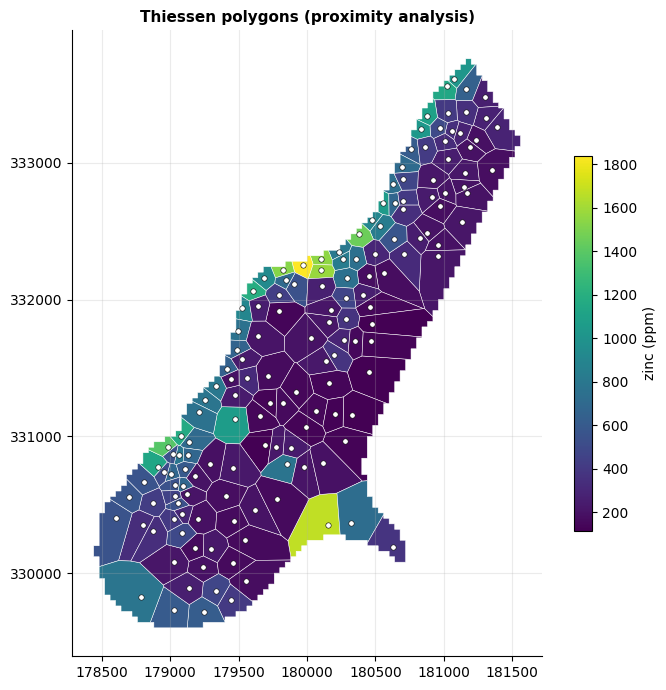

In [4]:
import shapely

half = _dx / 2
floodplain = shapely.union_all(
    shapely.box(grid_xy[:, 0] - half, grid_xy[:, 1] - half, grid_xy[:, 0] + half, grid_xy[:, 1] + half)
)
thiessen = Thiessen().fit(coords, values)
polys = thiessen.polygons(region=floodplain, crs="EPSG:28992")
print(f"{len(polys)} polygons, one per sample, clipped to the floodplain grid")

fig, ax = plt.subplots(figsize=(7, 7))
polys.plot(column="value", ax=ax, cmap="viridis", legend=True,
           legend_kwds={"label": "zinc (ppm)", "shrink": 0.6},
           edgecolor="white", linewidth=0.35)
ax.scatter(coords[:, 0], coords[:, 1], s=15, color="white", edgecolor="k", linewidth=0.4, zorder=3)
ax.set_title("Thiessen polygons (proximity analysis)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("thiessen_polygons.png", dpi=100, bbox_inches="tight")
plt.show()


***
## 6. Nearest Neighbour

The simplest possible interpolator: every prediction location copies its closest observation's value exactly.
It is the raster of the Thiessen partition from the previous section: every grid cell copies the value of
the sample whose polygon contains it. `Thiessen.predict` and `NearestNeighbor.predict` return the same numbers.


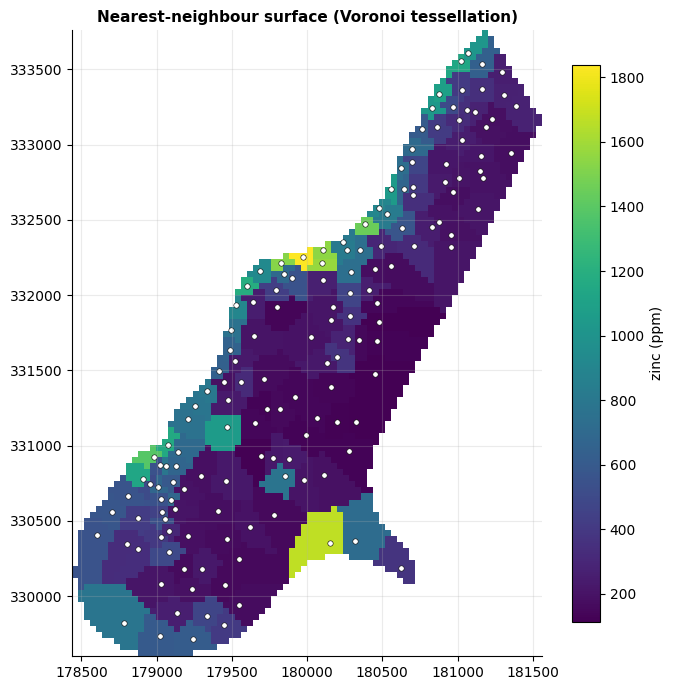

In [5]:
nn = NearestNeighbor()
nn.fit(coords, values)
pred_nn = nn.predict(grid_xy)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(to_raster(pred_nn), extent=EXTENT, origin="lower", cmap="viridis")
ax.scatter(coords[:, 0], coords[:, 1], s=15, color="white", edgecolor="k", linewidth=0.4)
plt.colorbar(im, ax=ax, label="zinc (ppm)", fraction=0.046)
ax.set_title("Nearest-neighbour surface (Voronoi tessellation)")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("nearest_surface.png", dpi=100, bbox_inches="tight")
plt.show()


The sharp polygon boundaries are the Voronoi cell edges made visible — exactly where the nearest sample
switches from one to another. This is a useful sanity check and a fast fallback, but as an interpolator it
throws away every piece of information except "which sample is closest," ignoring every other nearby reading
entirely.

***
## 7. TIN (Delaunay Linear)

`TIN` builds a Delaunay triangulation over the samples and interpolates **linearly** within each triangle — the
piecewise-linear analogue of natural-neighbour interpolation (true Sibson natural-neighbour interpolation is not
implemented in this library). Outside the convex hull of the samples, no triangle exists, so `TIN` falls
back to its `fill` strategy (`'nearest'` by default). On this floodplain that fill shows up along the edges
of the grid that sit outside the hull.


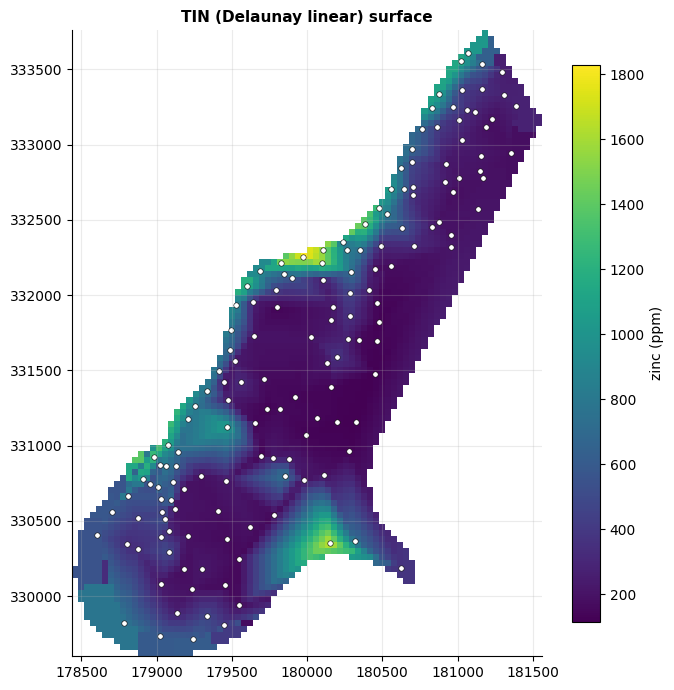

In [6]:
tin = TIN(fill="nearest")
tin.fit(coords, values)
pred_tin = tin.predict(grid_xy)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(to_raster(pred_tin), extent=EXTENT, origin="lower", cmap="viridis")
ax.scatter(coords[:, 0], coords[:, 1], s=15, color="white", edgecolor="k", linewidth=0.4)
plt.colorbar(im, ax=ax, label="zinc (ppm)", fraction=0.046)
ax.set_title("TIN (Delaunay linear) surface")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("tin_surface.png", dpi=100, bbox_inches="tight")
plt.show()


Within the triangulated interior, `TIN` produces a much smoother-looking surface than nearest-neighbour — no
sharp cell boundaries, just continuous linear gradients between samples. The boundary between the triangulated
interior and the `fill="nearest"` exterior is visible as a subtle change in texture near the domain edges,
worth remembering when interpreting predictions far from any sample.

***
## 8. Inverse Distance Weighting

$$
\hat{z}(\mathbf{s}_0) = \frac{\sum_i w_i\, z_i}{\sum_i w_i}, \qquad w_i = \frac{1}{d_i^{\,p}}
$$

`power` controls how sharply influence falls off with distance; `k` limits the weighted average to the $k$
nearest neighbours (all samples contribute if `k=None`); `radius` instead caps the neighbourhood by distance.


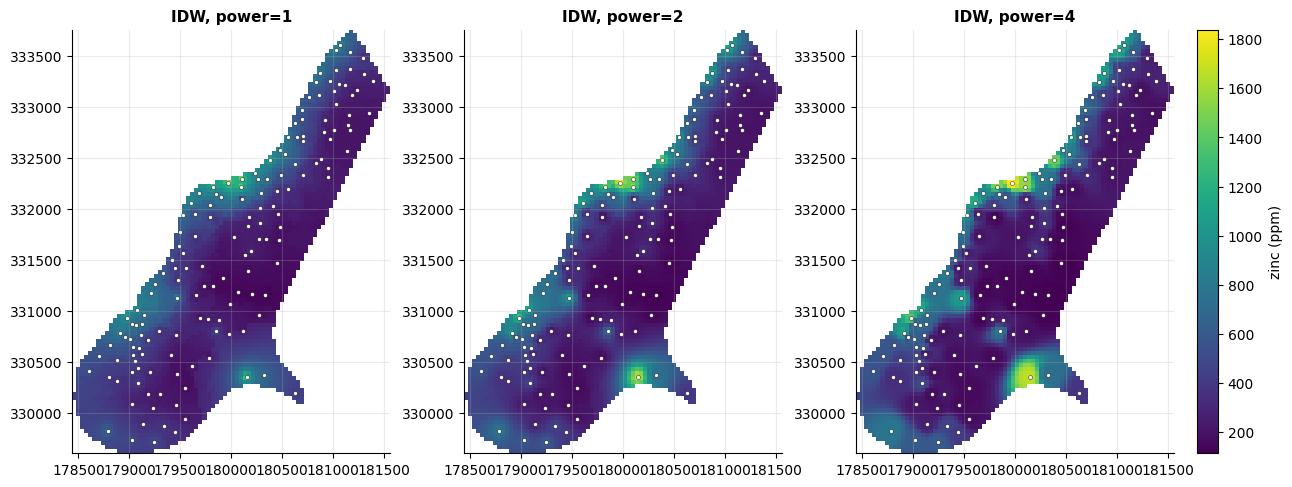

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
for ax, power in zip(axes, (1, 2, 4)):
    idw = IDW(power=power, k=12)
    idw.fit(coords, values)
    pred_idw = idw.predict(grid_xy)
    im = ax.imshow(to_raster(pred_idw), extent=EXTENT, origin="lower", cmap="viridis",
                   vmin=values.min(), vmax=values.max())
    ax.scatter(coords[:, 0], coords[:, 1], s=8, color="white", edgecolor="k", linewidth=0.3)
    ax.set_title(f"IDW, power={power}")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="zinc (ppm)", fraction=0.025, pad=0.02)
plt.savefig("idw_power_comparison.png", dpi=100, bbox_inches="tight")
plt.show()


Higher `power` sharpens the local "bullseye" pattern around each sample — at `power=4`, the surface looks
almost like a smoothed version of nearest-neighbour's Voronoi cells, since distant samples contribute
negligible weight. Lower `power` produces a much smoother, more globally averaged surface. Chapter 7.5 tunes
this trade-off by cross-validated RMSE rather than by eye.

***
## 9. Thin-Plate Spline

The thin-plate spline is, informally, the smoothest possible surface that still passes through every
observation — imagine bending a thin metal sheet to touch every data point while minimizing total curvature.
`ThinPlateSpline` is an `RBF` with the thin-plate kernel. `smoothing > 0` relaxes the exact-interpolation
requirement (Chapter 7.1, Section 5), useful when the observations themselves are noisy.


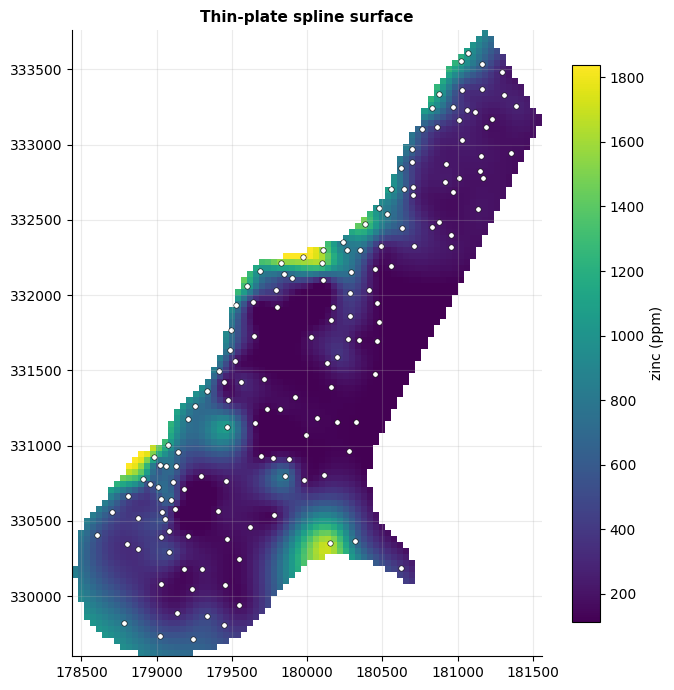

prediction range: -33.6 to 1976.8 (observed range: 113.0 to 1839.0)


In [8]:
rbf = ThinPlateSpline(smoothing=0.0)
rbf.fit(coords, values)
pred_rbf = rbf.predict(grid_xy)

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(to_raster(pred_rbf), extent=EXTENT, origin="lower", cmap="viridis",
               vmin=values.min(), vmax=values.max())
ax.scatter(coords[:, 0], coords[:, 1], s=15, color="white", edgecolor="k", linewidth=0.4)
plt.colorbar(im, ax=ax, label="zinc (ppm)", fraction=0.046)
ax.set_title("Thin-plate spline surface")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("rbf_surface.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"prediction range: {pred_rbf.min():.1f} to {pred_rbf.max():.1f} "
      f"(observed range: {values.min():.1f} to {values.max():.1f})")


Notice the predicted range printed above: the thin-plate spline's global smoothness constraint lets it
**overshoot** past the observed data range, especially toward the edges of the floodplain (visible as unusually
bright or dark patches far from any sample) — and here it overshoots badly enough to predict a **physically
impossible negative zinc concentration** on part of the grid, despite every observed value being strictly
positive (113 to 1,839 ppm). The polynomial trend can do the same thing. IDW and TIN, being local weighted
averages bounded by their neighbours' values, structurally cannot.

***
## 10. Comparing the Surfaces


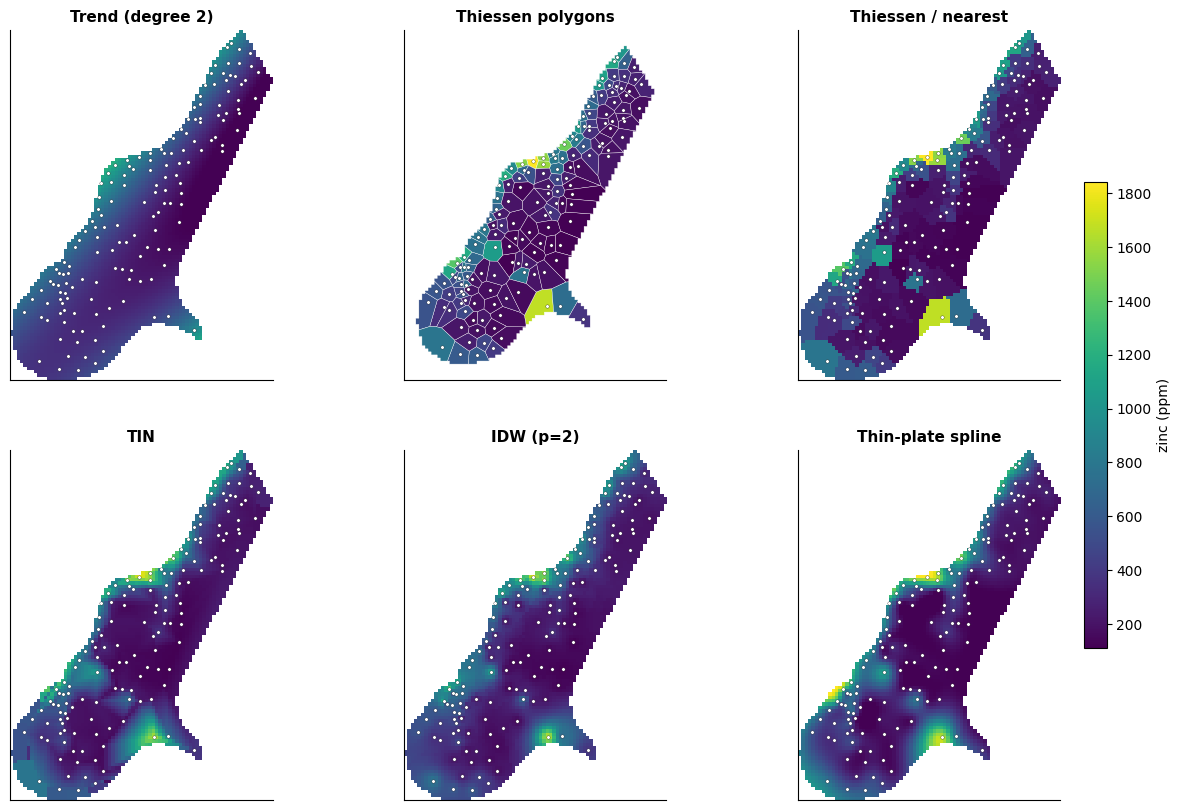

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pred_idw2 = IDW(power=2, k=12).fit(coords, values).predict(grid_xy)
panels = [
    ("Trend (degree 2)", pred_tr),
    ("Thiessen / nearest", thiessen.predict(grid_xy)),
    ("TIN", pred_tin),
    ("IDW (p=2)", pred_idw2),
    ("Thin-plate spline", pred_rbf),
]
# Six panels: five rasters plus the Thiessen polygon layer, on one color scale.
raster_axes = [axes[0, 0], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]
for ax, (name, pred) in zip(raster_axes, panels):
    im = ax.imshow(to_raster(pred), extent=EXTENT, origin="lower", cmap="viridis",
                   vmin=values.min(), vmax=values.max())
    ax.scatter(coords[:, 0], coords[:, 1], s=6, color="white", edgecolor="k", linewidth=0.2)
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
ax = axes[0, 1]
polys.plot(column="value", ax=ax, cmap="viridis", vmin=values.min(), vmax=values.max(),
           legend=False, edgecolor="white", linewidth=0.25)
ax.scatter(coords[:, 0], coords[:, 1], s=6, color="white", edgecolor="k", linewidth=0.2, zorder=3)
ax.set_title("Thiessen polygons")
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="zinc (ppm)", fraction=0.02, pad=0.02)
plt.savefig("deterministic_methods_comparison.png", dpi=100, bbox_inches="tight")
plt.show()


Side by side, the trade-off is visible directly: the trend's broad gradients, Thiessen's sharp service areas
(the polygon layer and the nearest-neighbour raster are the same partition), TIN's angular facets, IDW's
smooth bullseyes, and the spline's very smooth but occasionally overshooting surface. None of these panels
carries a confidence statement — that is exactly what Chapter 7.4's kriging adds. Chapter 7.5 replaces "which
looks smoothest" with an honest, cross-validated answer to "which actually predicts best."

***
## 11. Summary and Conclusions

This chapter fit the deterministic interpolators on the 155 Meuse topsoil samples and predicted zinc on the
same 3,103-cell floodplain grid, through one shared interface.

### What we did

1. Confirmed every interpolator in this Part shares `.fit` / `.predict` / `.predict_grid` / `.clone` / `.get_params`.
2. Fit polynomial trend surfaces of degree 1, 2, and 3 and read the in-sample $R^2$.
3. Built the Thiessen polygon layer (proximity analysis), clipped to the floodplain, and the matching nearest-neighbour raster.
4. Mapped TIN, IDW at three power values, and the thin-plate spline on the same samples and `meuse_grid.csv`.
5. **Found the thin-plate spline predicts a physically impossible negative zinc value** on part of the floodplain,
   despite every observed value being strictly positive. A polynomial trend surface can overshoot for the same
   reason. The local methods (IDW, TIN, Thiessen) stay inside the range of the observations they use.
6. Compared the surfaces on a shared color scale.

### Practical takeaways

- A trend surface describes the broad gradient. It is the wrong tool when the question is the value at a
  place between samples.
- Thiessen polygons answer "which sample is closest." Nearest neighbour is that answer on a grid.
- Higher IDW `power` values behave more like nearest neighbour; lower values behave more like a broad smoothing
  average. Treat `power` as a tunable hyperparameter (Chapter 7.5), not a fixed convention.
- Watch for spline and high-degree trend overshoot in sparse regions before treating the surface as a usable
  concentration.
- None of these methods produces a prediction variance. Every map here is a single best guess.

### Next steps

**Chapter 7.4 (Geostatistical Interpolation)** introduces the semivariogram and ordinary kriging — the method
that finally delivers the prediction uncertainty Chapter 7.1 argued deterministic methods cannot provide.


***
## 12. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Chorley, R. J. and Haggett, P. (1965). Trend-surface mapping in geographical research. *Transactions of the Institute of British Geographers*, 37. | Polynomial trend surfaces as a geographical method |
| Thiessen, A. H. (1911). Precipitation averages for large areas. *Monthly Weather Review*, 39. | The polygon proximity method |
| Shepard, D. (1968). A two-dimensional interpolation function for irregularly-spaced data. *Proceedings of the 1968 ACM National Conference*. | The original inverse-distance-weighting formulation |
| Duchon, J. (1977). Splines minimizing rotation-invariant semi-norms in Sobolev spaces. In *Constructive Theory of Functions of Several Variables*. Springer. | Thin-plate splines |
| Sibson, R. (1981). A brief description of natural neighbour interpolation. In *Interpreting Multivariate Data*. Wiley. | The natural-neighbour method TIN's linear interpolation approximates |

### In this library

| Object | Role |
|---|---|
| `TrendSurface`, `Thiessen`, `thiessen_polygons` | Polynomial trend and proximity polygons |
| `NearestNeighbor`, `TIN`, `IDW`, `ThinPlateSpline` | The other surfaces in this chapter |
| Chapter 7.4 | Adds the prediction variance these methods cannot provide |
| Chapter 7.5 | Replaces visual comparison with cross-validated RMSE |
